# Credit Default Risk - Visual Analysis

Charts and findings from the exploration and modeling of the Data: Give Me Some Credit from Kaggle, about 150,000 borrowers.

** The goal:** to predict which borrowers are likely to default, and show the main risk drivers visually.

This notebook loads the cleaned data (built by the SQL pipeline), recreates the key findings as charts, and visuallizes the model's precision-recall tradeoff.


# 1. Load the cleaned data

The data was cleaned in SQL (sentinel codes capped, missing income imputed with a flag, impossible ages removed - see FINDINGS.md). Here we just pull the finished `credit_clean` table out of the SQLite database into pandas so we can chart it.

In [6]:
# Import the tools:
#   sqlite3  -> talk to the database file
#   pandas   -> hold and manipulate the data as a table (DataFrame)
#   matplotlib  -> draw the charts
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Open a connection to the database file built by src/load_to_sqlite.py
conn = sqlite3.connect("data/credit.db")

# Run a SQL query and load the result straight into a DataFrame.
# credit_clean is the cleaned table (not raw_credit, the messy original).
df = pd.read_sql("SELECT * FROM credit_clean", conn)

#Always close the connection when done reading.
conn.close()

# Sanity checks: confirm the expected ~150k rows, and peek at the data.
print("Loaded", len(df),"rows")
df.head()  # in a notebook, the last line of a cell displays automatically


Loaded 149999 rows


,serious_dlq_2yrs,age,revolving_utilization,debt_ratio,monthly_income,income_was_missing,num_open_credit_lines,num_real_estate_loans,num_dependents,total_past_due
0,1,45,0.766127,0.802982,9120.0,0,13,6,2.0,2
1,0,40,0.957151,0.121876,2600.0,0,4,0,1.0,0
2,0,38,0.658180,0.085113,3042.0,0,2,0,0.0,2
3,0,30,0.233810,0.036050,3300.0,0,5,0,0.0,0
4,0,49,0.907239,0.024926,63588.0,0,7,1,0.0,1


The table above confirms the cleaned data is loadedd correctly:
One row per borrower, with the target (`serious_dlq_2yrs`,1 = defaulted) and teh cleaned features, including the engineered `total_past_due` and the ` income_was_missing` flag.

## 2. Default rate by credit utilization (the strongest predictor)

Utilization = current balance / credit limit. It measures how "maxed out" a borrower is - a proxy for current financial strain.

We bucket borrowers into utilization bands and compute each band's default rate. In SQL this was a CASE WHEN + GROUP BY; here we do the same with pandas (`pd.cut` to bucket, `groupby` to aggregate).

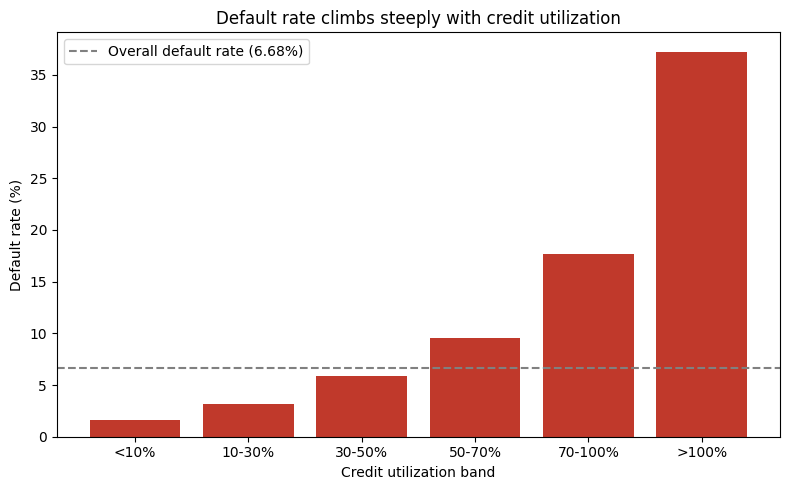

In [8]:
# We define the band edges and readable labels.
# These match the bands used in the SQL exploration.
bins = [0, 0.1, 0.3, 0.5, 0.7, 1.0, 2.1]
labels =["<10%", "10-30%", "30-50%", "50-70%","70-100%", ">100%"]

# pd.cut assigns each borrower to a band based on their utilization.
# (This is teh pandas equivalent of the SQL CASE WHEN ladder.)
df["util_band"] = pd.cut(df["revolving_utilization"], bins=bins, labels=labels)

# Group by band and compute the default rate: 
# the target is 0/1, so its mean IS the share who defaulted. x100 = percent.
util_rates = df.groupby("util_band", observed=True)["serious_dlq_2yrs"].mean() * 100

# --- Build the chart ---
fig, ax = plt.subplots(figsize=(8,5))   # a blank canvas, 8x5 inches
ax.bar(util_rates.index, util_rates.values, color="#c0392b")  # bars: bands on x, rates on y
ax.axhline(y=6.68, color="gray", linestyle="--", label="Overall default rate (6.68%)")    # dashed line = overall baseline

# Labels and title: a chart without these is unreadable to a stranger.
ax.set_xlabel("Credit utilization band")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate climbs steeply with credit utilization")
ax.legend()                             # shows the baseline label

plt.tight_layout()      # fixes spacing
plt.show()         # render the chart below cell


**Reading:** default risk rises monotonically with utilization -  from under 2% for borrowers using <10% of their credit to ~37% for those over their limit (a ~20x spread). The rate crosses the overall baseline around 50% utilization. This made utilization the model's strongest prodictor  (odds ratio 2.18).

## 3. Default rate by age

Age was a clean protective factor in the exploration: younger borrowers default more, older borrowers less. Same method as above - bucket into bands, compute  each band's default rate. 

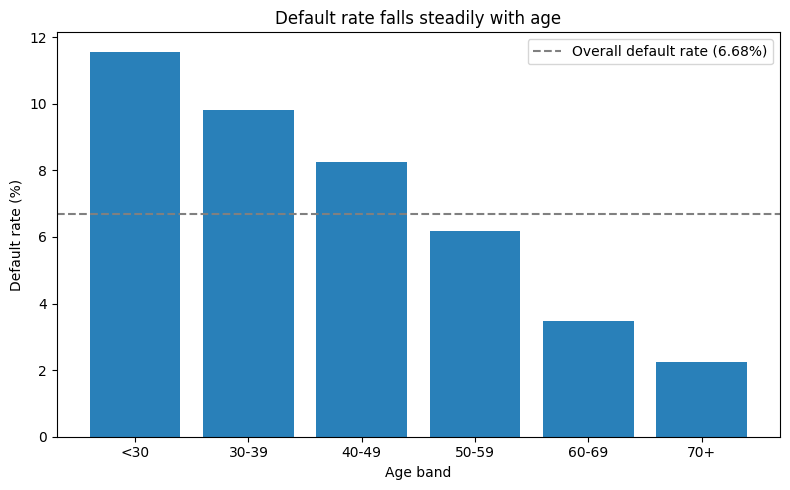

In [13]:
bins = [18, 30, 40, 50, 60, 70, 110]
labels = ["<30", "30-39", "40-49", "50-59", "60-69", "70+"] 

df["Age_band"] = pd.cut(df["age"], bins=bins, labels=labels)

age_rates = df.groupby("Age_band", observed=True)["serious_dlq_2yrs"].mean() * 100

fig, ax = plt.subplots(figsize=(8,5))   # a blank canvas, 8x5 inches
ax.bar(age_rates.index, age_rates.values, color="#2980b9")  # bars: bands on x, rates on y
ax.axhline(y=6.68, color="gray", linestyle="--", label="Overall default rate (6.68%)")    # dashed line = overall baseline

ax.set_xlabel("Age band")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate falls steadily with age")
ax.legend()                             # shows the baseline label

plt.tight_layout()       # fixes spacing
plt.show()         # render the chart below cell

**Reading:** The default rate decreases as age rises, from approximately 11.7% for borrowers under 30 to approximately 2.3% for those 70+. It crosses the 6.68% overall baseline rate around 50-59. This means older borrowers are meaningfully safer - consistent with the model's negative coefficient on age. 

## 4. The precision-recall tradeoff (threshold tuning)

The model outputs a probabolity per borrower; a threshold turns it into a yes/no decision. With rare defaults (6.68%), the default 0.50 threshold caught only 6% of defaulters despite 93% accuracy.

Lowering the threshold catches more defaulters (recall rises) at the cost of more false alarms (precision falls). Where to sit on this curve is a business decision - the cost of a missed default vs. a declined good customer. 

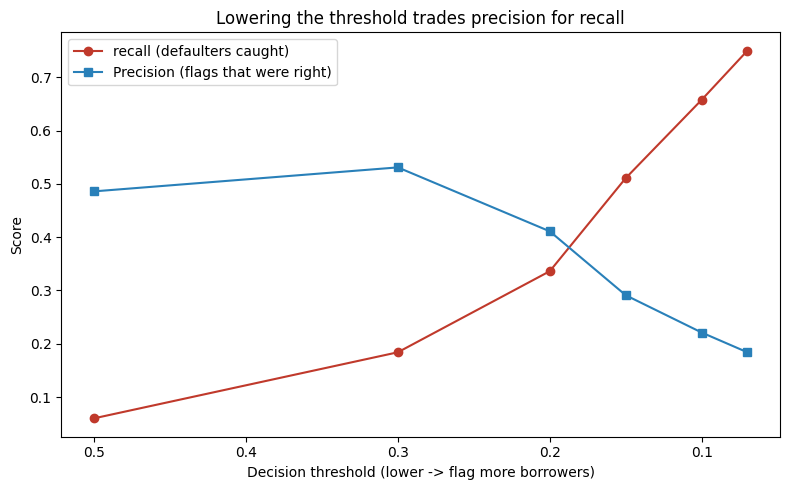

In [17]:
# Thresholds - tuning results from model.py (test set, 30,000 borrowers)
thresholds = [0.50, 0.30, 0.20, 0.15, 0.10, 0.07]
precision  = [0.486, 0.531, 0.411, 0.291, 0.221, 0.184]
recall     = [0.060, 0.184, 0.3362, 0.511, 0.658, 0.750]

fig, ax = plt.subplots(figsize=(8, 5))

#Two lines on the same axes - one per metric. Markets show the actual
#measured points; the lines just connect them.
ax.plot(thresholds, recall, marker="o", color="#c0392b", label="recall (defaulters caught)")
ax.plot(thresholds, precision, marker="s", color="#2980b9", label="Precision (flags that were right)")

#Invert the x-axis so "lowering the threshold" reads left-to-right,
#matching teh story" as we lower the bar, recall climbs.
ax.invert_xaxis()

ax.set_xlabel("Decision threshold (lower -> flag more borrowers)")
ax.set_ylabel("Score")
ax.set_title("Lowering the threshold trades precision for recall")
ax.legend()
plt.tight_layout()
plt.show()

**Reading:** We see that as the threshold drops, recall climbs steeply with (6% of defaulters caught at 0.50 -> 75% at 0.07) while precision falls (49% -> 18%) - at 0.07 we catch three-quarters of defaulters but we generate 6,662 false alarms. The two metrics pull againts each other: catching more defaulters necessarily means flagging more good borrowers. The optimal threshold is therefore a business decision, which is set by the relative cost of a missed default vesrus a declined good customer - a lender for whom defaults are expensive would sit low on this curve.